<a href="https://colab.research.google.com/github/MiguelAngeloTr/Aprendizaje_Automatico/blob/main/Entrega_6/Clasificacion_de_celulas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Paso 1: Subir archivo desde tu computadora
from google.colab import files
uploaded = files.upload()

Saving BaseDatos_CelulasSangre_Train.zip to BaseDatos_CelulasSangre_Train.zip
Saving BaseDatos_CelulasSangre_Test.zip to BaseDatos_CelulasSangre_Test.zip


#***SECCIÓN 1: EXTRACCIÓN DE CARACTERÍSTICAS, EDA y PCA***


EDA

In [2]:
import zipfile
import os

# Lista de archivos ZIP a descomprimir
zips = [
    "BaseDatos_CelulasSangre_Test.zip",
    "BaseDatos_CelulasSangre_Train.zip"
]

# Carpeta donde se descomprimirá
output_dir = "celulas_descomprimidas"

os.makedirs(output_dir, exist_ok=True)

for zip_file in zips:
    with zipfile.ZipFile(zip_file, 'r') as z:
        print(f"Descomprimiendo {zip_file} ...")
        z.extractall(output_dir)

print("Listo: ambos archivos fueron descomprimidos")




Descomprimiendo BaseDatos_CelulasSangre_Test.zip ...
Descomprimiendo BaseDatos_CelulasSangre_Train.zip ...
Listo: ambos archivos fueron descomprimidos


In [3]:
#Cargar imagenes de train
import cv2
import os
import numpy as np

ruta = "celulas_descomprimidas"

clases_train = {
    "Basofilos_train": 0,
    "Eritroblasto_train": 1
}

X_train = []
y_train = []

for carpeta, etiqueta in clases_train.items():
    path_carpeta = os.path.join(ruta, carpeta)
    for archivo in os.listdir(path_carpeta):
        img_path = os.path.join(path_carpeta, archivo)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            print("No se pudo leer:", img_path)
            continue

        img = cv2.resize(img, (128,128))  # tamaño estándar
        X_train.append(img.flatten())
        y_train.append(etiqueta)

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (120, 16384)
y_train shape: (120,)


In [4]:

!ls celulas_descomprimidas/Inference


Basofilos_inference  Eritoblastos_inference


In [15]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.measure import shannon_entropy
from skimage.feature import graycomatrix, graycoprops

ruta = "celulas_descomprimidas"

# Diccionarios de clases
clases = {
    "Basofilos_train": 0,
    "Eritroblasto_train": 1
}

clases_inf = {
    "Basofilos_inference": 0,
    "Eritoblastos_inference": 1
}

# Lista donde almacenaremos TODA la info
metricas = []

def calcular_metricas(img_gray):
    """Calcula entropía, contraste GLCM, homogeneidad, densidad y bordes."""

    # ENTROPÍA
    ent = shannon_entropy(img_gray)

    # GLCM
    glcm = graycomatrix(img_gray,
                        distances=[1],
                        angles=[0],
                        levels=256,
                        symmetric=True,
                        normed=True)

    contraste = graycoprops(glcm, 'contrast')[0][0]
    homogeneidad = graycoprops(glcm, 'homogeneity')[0][0]

    # DENSIDAD (pixeles oscuros)
    densidad = np.mean(img_gray < 128)

    # DENSIDAD DE BORDES
    edges = cv2.Canny(img_gray, 100, 200)
    dens_bordes = np.mean(edges > 0)

    return ent, contraste, homogeneidad, densidad, dens_bordes


def procesar_carpeta(base_path, clases_dict):
    """Carga imágenes, calcula métricas y las agrega a la tabla."""
    for carpeta, etiqueta in clases_dict.items():
        path_completo = os.path.join(base_path, carpeta)

        for archivo in os.listdir(path_completo):
            img_path = os.path.join(path_completo, archivo)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            # Redimensionamos por consistencia (128x128)
            img = cv2.resize(img, (128, 128))

            ent, cont, hom, dens, dens_b = calcular_metricas(img)

            metricas.append({
                "archivo": archivo,
                "clase": carpeta,
                "etiqueta": etiqueta,
                "entropia": ent,
                "contraste": cont,
                "homogeneidad": hom,
                "densidad_oscuros": dens,
                "densidad_bordes": dens_b
            })


# Procesar TRAIN
procesar_carpeta(ruta, clases)

# Procesar INFERENCE
procesar_carpeta(os.path.join(ruta, "Inference"), clases_inf)

df = pd.DataFrame(metricas)
df.head()



,archivo,clase,etiqueta,entropia,contraste,homogeneidad,densidad_oscuros,densidad_bordes
0,BA_4118.jpg,Basofilos_train,0,5.759945,176.721088,0.363428,0.080811,0.107971
1,BA_174705.jpg,Basofilos_train,0,5.561098,146.241265,0.402623,0.081177,0.075928
2,BA_556332.jpg,Basofilos_train,0,5.769350,139.358883,0.399622,0.066895,0.085632
3,BA_289279.jpg,Basofilos_train,0,5.930780,239.089505,0.367024,0.081055,0.133911
4,BA_636364.jpg,Basofilos_train,0,5.652235,195.638841,0.401482,0.078735,0.092468


In [22]:
df_prom = df.groupby("clase")[[ # Select desired columns BEFORE calling .mean()
    "entropia",
    "contraste",
    "homogeneidad",
    "densidad_oscuros",
    "densidad_bordes"
]].mean()

df_prom

,entropia,contraste,homogeneidad,densidad_oscuros,densidad_bordes
clase,,,,,
Basofilos_inference,5.856274,166.114358,0.383013,0.077454,0.084180
Basofilos_train,5.727595,191.270986,0.394368,0.082222,0.098323
Eritoblastos_inference,4.790329,40.035458,0.521305,0.021387,0.026538
Eritroblasto_train,5.274676,55.395608,0.453100,0.024625,0.052251


<Figure size 1200x600 with 0 Axes>

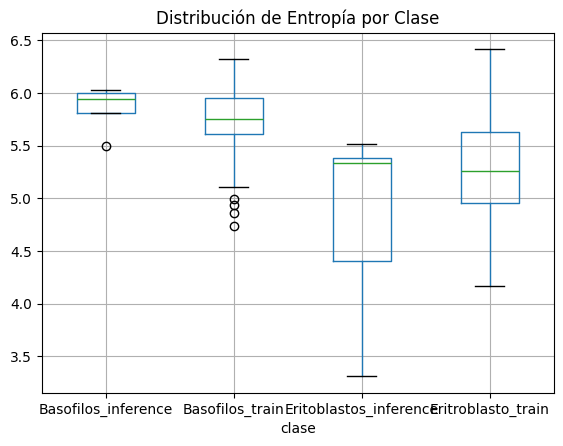

<Figure size 1200x600 with 0 Axes>

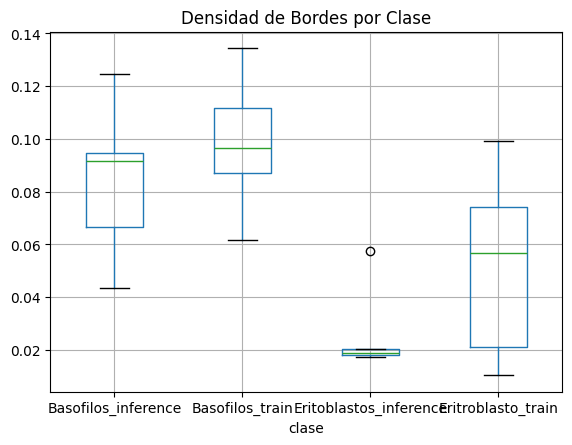

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df.boxplot(column="entropia", by="clase")
plt.title("Distribución de Entropía por Clase")
plt.suptitle("")
plt.show()

plt.figure(figsize=(12,6))
df.boxplot(column="densidad_bordes", by="clase")
plt.title("Densidad de Bordes por Clase")
plt.suptitle("")
plt.show()


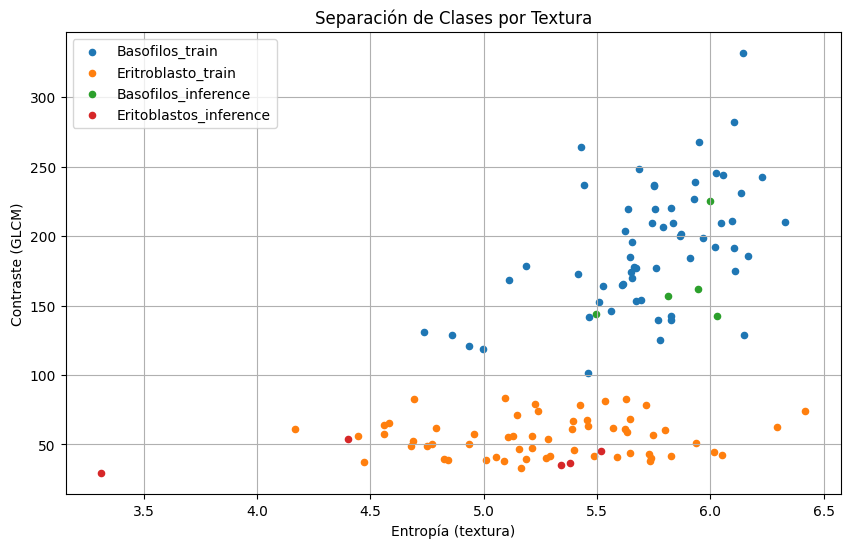

In [24]:
plt.figure(figsize=(10,6))

for clase in df["clase"].unique():
    temp = df[df["clase"] == clase]
    plt.scatter(temp["entropia"], temp["contraste"], label=clase, s=20)

plt.xlabel("Entropía (textura)")
plt.ylabel("Contraste (GLCM)")
plt.title("Separación de Clases por Textura")
plt.legend()
plt.grid()
plt.show()


PCA

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Seleccionamos solo las columnas de textura
features = ["entropia", "contraste", "homogeneidad", "densidad_oscuros", "densidad_bordes"]
X = df[features].values

# Normalizamos por seguridad (importante en PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Etiquetas para graficar colores
y = df["clase"].values

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por PC1 y PC2:", pca.explained_variance_ratio_)


Varianza explicada por PC1 y PC2: [0.74731718 0.16819848]


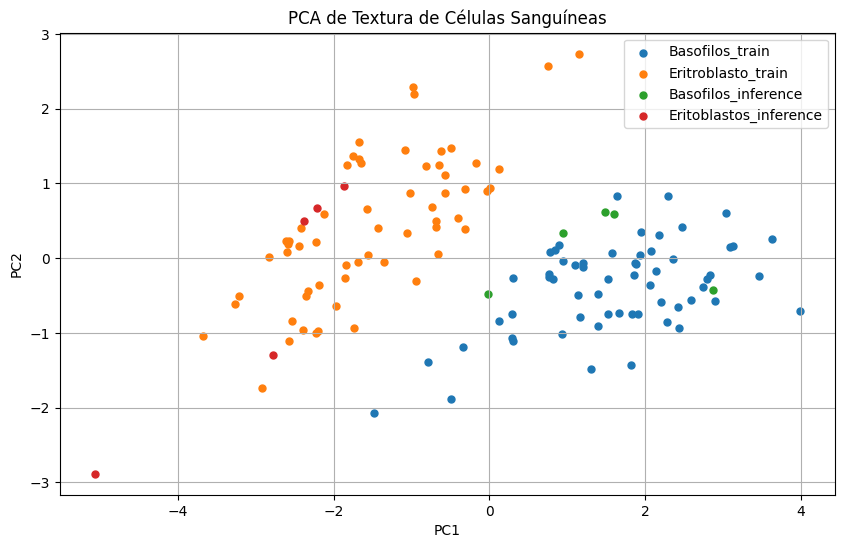

In [26]:
plt.figure(figsize=(10,6))

for clase in df["clase"].unique():
    idx = df["clase"] == clase
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], s=25, label=clase)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA de Textura de Células Sanguíneas")
plt.legend()
plt.grid()
plt.show()


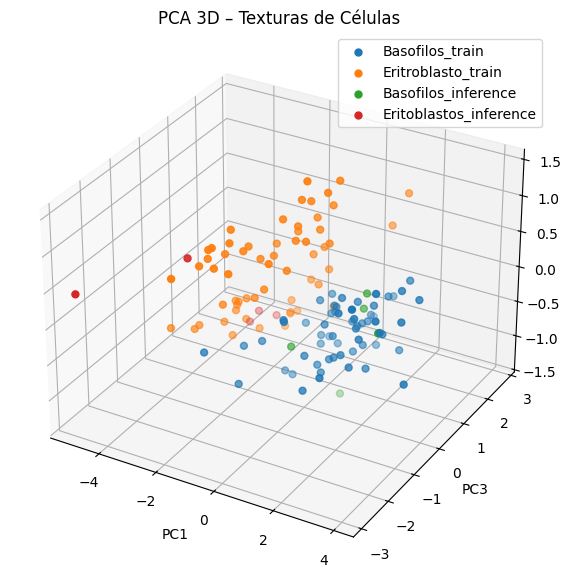

In [27]:
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for clase in df["clase"].unique():
    idx = df["clase"] == clase
    ax.scatter(X_pca3[idx, 0], X_pca3[idx, 1], X_pca3[idx, 2], s=25, label=clase)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_ylabel("PC3")
ax.set_title("PCA 3D – Texturas de Células")
ax.legend()
plt.show()


#***SECCIÓN 2: CLASIFICACIÓN UTILIZANDO APRENDIZAJE SUPERVISADO***
